# CISC 886 — Section 5: Fine-Tuning Qwen2.5-1.5B on Banking Dataset
**Model:** unsloth/Qwen2.5-1.5B-Instruct  
**Dataset:** bitext/Bitext-retail-banking-llm-chatbot-training-dataset  
**Technique:** QLoRA (4-bit) via Unsloth  
**Hardware:** Google Colab T4 GPU

## Cell 1 — Install Libraries

In [ ]:
!pip install unsloth datasets trl peft -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0

## Cell 2 — GPU Info (Screenshot this!)

In [ ]:
import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"CUDA version: {torch.version.cuda}")

GPU: Tesla T4
VRAM: 15.6 GB
CUDA version: 12.8


## Cell 3 — Load Base Model (Qwen2.5-1.5B)

In [ ]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 2048

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen2.5-1.5B-Instruct",
    max_seq_length = max_seq_length,
    dtype = torch.float16,
    load_in_4bit = True,   # QLoRA — saves VRAM on T4
)

print("✅ Qwen2.5-1.5B Model loaded successfully!")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
✅ Qwen2.5-1.5B Model loaded successfully!


## Cell 4 — 🔴 BASE MODEL TEST (Before Fine-tuning)
### ⚠️ خد screenshot من الـ output ده للريبورت

In [ ]:
# Test the BASE model BEFORE any fine-tuning
FastLanguageModel.for_inference(model)

def test_model(prompt_text, max_tokens=150):
    prompt = f"""### Instruction:\n{prompt_text}\n\n### Response:\n"""
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = model.generate(
        **inputs,
        max_new_tokens = max_tokens,
        temperature = 0.7,
        do_sample = True,
    )
    full = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return full.split("### Response:")[-1].strip()

# These same prompts will be used after fine-tuning for comparison
prompts = [
    "How do I reset my online banking password?",
    "What are the fees for international wire transfers?",
    "How can I dispute a transaction on my account?"
]

print("=" * 60)
print("🔴 BASE MODEL RESPONSES (Before Fine-tuning)")
print("=" * 60)
for p in prompts:
    print(f"\n📌 Prompt: {p}")
    print(f"🤖 Response:\n{test_model(p)}")
    print("-" * 60)

🔴 BASE MODEL RESPONSES (Before Fine-tuning)

📌 Prompt: How do I reset my online banking password?


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12

🤖 Response:
To reset your online banking password, you can follow these steps:

1. Log in to your online banking account.
2. Look for the "My Account" or "Profile" section on the homepage.
3. Click on the option that says "Change Password."
4. Enter your current password and select a new one.
5. Confirm the new password by re-entering it.
6. Follow any additional prompts or instructions provided.

By following these steps, you should be able to successfully reset your online banking password. Remember to keep your personal information secure and not share your passwords with anyone else. ### Explanation:
The response provides a clear and concise guide on how to reset an online banking password. It includes all necessary steps such as logging into the
------------------------------------------------------------

📌 Prompt: What are the fees for international wire transfers?


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🤖 Response:
International wire transfer fees can vary depending on several factors, including the bank or financial institution you're using, the currency involved, and the country of origin. Here's a general overview of some common fees associated with international wire transfers:

1. **Transfer Fee**: This is typically a flat fee that covers the cost of processing the transaction. The amount varies by bank but usually ranges from $5 to $20 per transaction.

2. **Currency Conversion Fee**: If your funds come in one currency and you want to send them to another currency (for example, sending dollars to euros), there will be an additional charge to convert between those currencies. This conversion fee is often calculated based on the current exchange rate.

3. **Transaction Fee**: Some banks
------------------------------------------------------------

📌 Prompt: How can I dispute a transaction on my account?


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


🤖 Response:
To dispute a transaction on your account, follow these steps:

1. Log in to your online banking or credit card statement.
2. Look for the "Report Fraud" or "Fraud Report" option. This will allow you to report the fraudulent activity.
3. Follow the prompts to provide as much information about the fraud as possible.
4. Submit the report and wait for the bank to investigate.

Note: Not all banks offer this feature, so it's important to check with your specific financial institution. Additionally, if you're unsure whether the transaction is fraudulent, consider reaching out to customer service for further assistance. ### Explanation:
The response provided outlines the general process of disputing a transaction on an account, which typically involves logging into the banking
------------------------------------------------------------


## Cell 5 — Add LoRA Adapters (PEFT)

In [ ]:
# Switch back to training mode before adding LoRA
FastLanguageModel.for_training(model)

model = FastLanguageModel.get_peft_model(
    model,
    r = 16,                          # LoRA rank
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,                 # scaling factor = r for stable training
    lora_dropout = 0.05,             # light regularization
    bias = "none",
    use_gradient_checkpointing = "unsloth",  # saves extra VRAM
    random_state = 42,
)

print("✅ LoRA adapters added!")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.4.8 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


✅ LoRA adapters added!
Trainable parameters: 18,464,768
Total parameters: 1,036,449,280


## Cell 6 — Load & Split Dataset (No Data Leakage)

In [ ]:
from datasets import load_dataset

ds = load_dataset("bitext/Bitext-retail-banking-llm-chatbot-training-dataset")

full_dataset = ds['train']
print(f"Total samples: {len(full_dataset)}")
print(f"Features: {full_dataset.features}")
print(f"\n=== Verbatim Sample for Report ===")
print(full_dataset[0])

# ✅ Split BEFORE any processing to avoid data leakage
# Fixed seed=42 ensures reproducibility
train_temp = full_dataset.train_test_split(test_size=0.2, seed=42)
val_test   = train_temp['test'].train_test_split(test_size=0.5, seed=42)

# Take subset to finish within Colab time limit
train_data = train_temp['train'].select(range(3000))
val_data   = val_test['train'].select(range(300))
test_data  = val_test['test']

print(f"\n✅ Train: {len(train_data)} samples")
print(f"✅ Val:   {len(val_data)} samples")
print(f"✅ Test:  {len(test_data)} samples")

README.md: 0.00B [00:00, ?B/s]

bitext-retail-banking-llm-chatbot-traini(…):   0%|          | 0.00/7.87M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25545 [00:00<?, ? examples/s]

Total samples: 25545
Features: {'tags': Value('string'), 'instruction': Value('string'), 'category': Value('string'), 'intent': Value('string'), 'response': Value('string')}

=== Verbatim Sample for Report ===
{'tags': 'BCIPZ', 'instruction': 'I would like to acivate a card, can you help me?', 'category': 'CARD', 'intent': 'activate_card', 'response': 'I\'m here to assist you with that! Activating your card is an important step to starting and enjoying its benefits. Here\'s how you can activate your card:\n\n1. Locate the activation instructions: Depending on the card issuer, you may find the activation instructions on a sticker attached to the card itself, in the welcome package, or on the issuer\'s website.\n\n2. Visit the card issuer\'s activation website: Using your computer or mobile device, open a web browser and navigate to the card issuer\'s website. Look for the activation page or section.\n\n3. Enter the required information: Follow the prompts on the activation page and prov

## Cell 7 — Save Dataset as Parquet Files

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Create output directory
os.makedirs("/content/drive/MyDrive/banking_data", exist_ok=True)

# Save all 3 splits as parquet
train_data.to_parquet("/content/drive/MyDrive/banking_data/train.parquet")
val_data.to_parquet("/content/drive/MyDrive/banking_data/val.parquet")
test_data.to_parquet("/content/drive/MyDrive/banking_data/test.parquet")

# Verify files saved correctly
print("✅ Parquet files saved to Google Drive!")
print("\n📁 File sizes:")
for split in ['train', 'val', 'test']:
    path = f"/content/drive/MyDrive/banking_data/{split}.parquet"
    size = os.path.getsize(path) / 1e6
    print(f"   {split}.parquet — {size:.1f} MB")

Mounted at /content/drive


Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

✅ Parquet files saved to Google Drive!

📁 File sizes:
   train.parquet — 1.2 MB
   val.parquet — 0.1 MB
   test.parquet — 1.0 MB


## Cell 8 — EDA (3 Figures for Report)

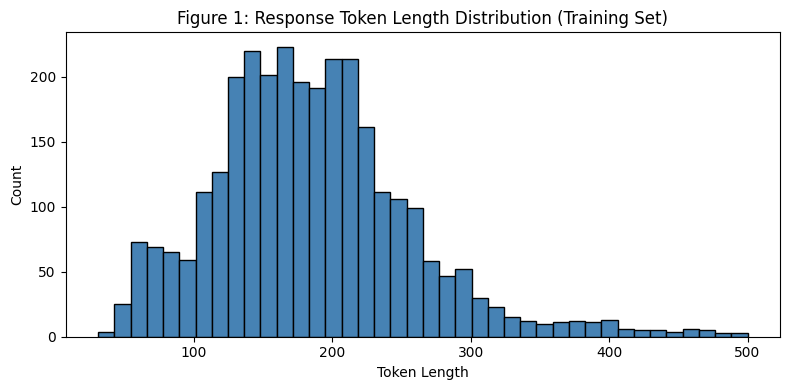

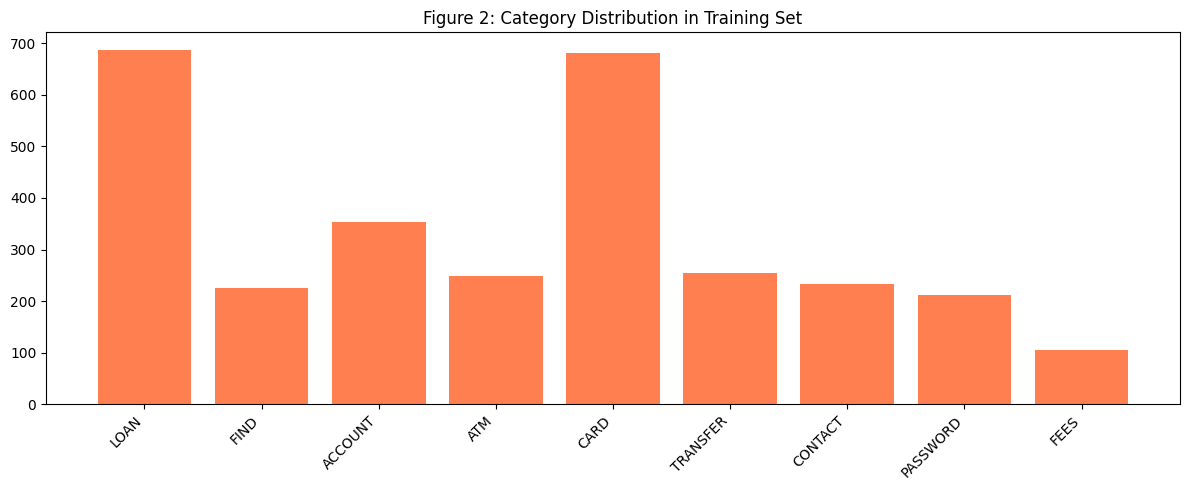

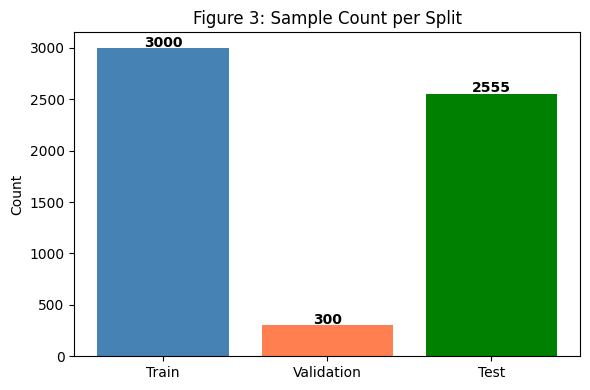

📊 Avg token length: 185.4
📊 Max token length: 500
📊 Min token length: 31


In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# Figure 1: Token length distribution
lengths = [len(tokenizer.encode(r)) for r in train_data['response']]

plt.figure(figsize=(8,4))
plt.hist(lengths, bins=40, color='steelblue', edgecolor='black')
plt.xlabel("Token Length")
plt.ylabel("Count")
plt.title("Figure 1: Response Token Length Distribution (Training Set)")
plt.tight_layout()
plt.savefig("/content/token_distribution.png", dpi=150)
plt.show()

# Figure 2: Category distribution
intents = Counter(train_data['category'])
plt.figure(figsize=(12,5))
plt.bar(intents.keys(), intents.values(), color='coral')
plt.xticks(rotation=45, ha='right')
plt.title("Figure 2: Category Distribution in Training Set")
plt.tight_layout()
plt.savefig("/content/category_distribution.png", dpi=150)
plt.show()

# Figure 3: Sample count per split
plt.figure(figsize=(6,4))
splits = ['Train', 'Validation', 'Test']
counts = [len(train_data), len(val_data), len(test_data)]
plt.bar(splits, counts, color=['steelblue', 'coral', 'green'])
plt.title("Figure 3: Sample Count per Split")
plt.ylabel("Count")
for i, v in enumerate(counts):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig("/content/split_distribution.png", dpi=150)
plt.show()

print(f"📊 Avg token length: {sum(lengths)/len(lengths):.1f}")
print(f"📊 Max token length: {max(lengths)}")
print(f"📊 Min token length: {min(lengths)}")

## Cell 9 — Format Prompts

In [ ]:
def format_prompt(example):
    """Format dataset into instruction-response format for fine-tuning"""
    text = f"""### Instruction:\n{example['instruction']}\n\n### Response:\n{example['response']}"""
    return {"text": text}

train_data = train_data.map(format_prompt)
val_data   = val_data.map(format_prompt)

print("✅ Data formatted!")
print("\n=== Formatted Sample ===")
print(train_data[0]['text'])

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

✅ Data formatted!

=== Formatted Sample ===
### Instruction:
help me seeing the loan payments

### Response:
I'm here to assist you with checking your loan payments. To view your loan payments, please follow these simple steps:

1. Log in to your account on our website.
2. Navigate to the "Loan" or "Loan Payments" section.
3. You should be able to see a list of your loan payments, including the dates and amounts.

If you're having trouble finding the section or accessing your loan payment information, please let me know. I'll be glad to provide further guidance.


## Cell 10 — Fine-Tuning (SFT with LoRA)

In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_data,
    eval_dataset = val_data,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    args = TrainingArguments(
        output_dir = "/content/outputs",
        per_device_train_batch_size = 2,   # T4 15GB
        gradient_accumulation_steps = 4,   # effective batch = 8
        warmup_steps = 50,
        num_train_epochs = 1,              # 1 epoch ~10 min on T4
        learning_rate = 2e-4,
        fp16 = True,
        logging_steps = 10,
        eval_strategy = "steps",
        eval_steps = 100,
        save_strategy = "steps",
        save_steps = 200,
        load_best_model_at_end = True,
        report_to = "none",
        seed = 42,
    ),
)

print("🚀 Starting training...")
trainer_stats = trainer.train()
print("✅ Training complete!")
print(f"⏱️ Time: {trainer_stats.metrics['train_runtime']/60:.1f} minutes")
print(f"📉 Final loss: {trainer_stats.metrics['train_loss']:.4f}")

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/3000 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/300 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🚀 Starting training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,000 | Num Epochs = 1 | Total steps = 375
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
100,0.793142,0.788259
200,0.701763,0.710708
300,0.657152,0.678553
375,0.636320,0.668436


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

✅ Training complete!
⏱️ Time: 12.8 minutes
📉 Final loss: 0.7824


## Cell 11 — Training Loss Curve (Screenshot this!)

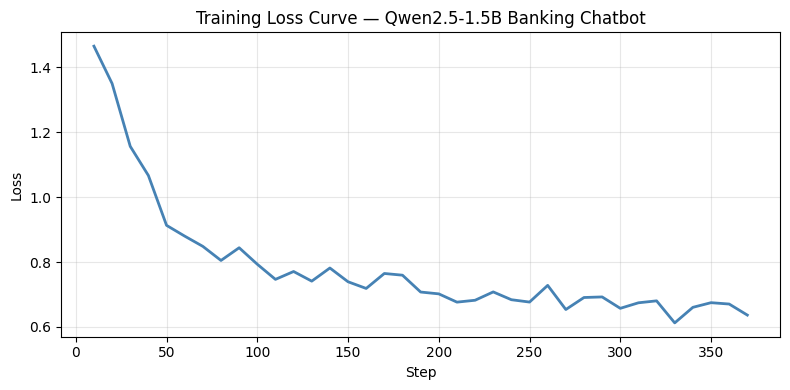

Initial loss: 1.4658
Final loss:   0.6363


In [ ]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history
train_loss = [(x['step'], x['loss']) for x in logs if 'loss' in x]
steps, losses = zip(*train_loss)

plt.figure(figsize=(8,4))
plt.plot(steps, losses, color='steelblue', linewidth=2)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve — Qwen2.5-1.5B Banking Chatbot")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/training_loss.png", dpi=150)
plt.show()

print(f"Initial loss: {losses[0]:.4f}")
print(f"Final loss:   {losses[-1]:.4f}")

## Cell 12 — 🟢 FINE-TUNED MODEL TEST (After Fine-tuning)
### ⚠️ خد screenshot من الـ output ده وقارنه بـ Cell 4

In [ ]:
FastLanguageModel.for_inference(model)

def test_model(prompt_text, max_tokens=150):
    prompt = f"""### Instruction:\n{prompt_text}\n\n### Response:\n"""
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = model.generate(
        **inputs,
        max_new_tokens = max_tokens,
        temperature = 0.7,
        do_sample = True,
    )
    full = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return full.split("### Response:")[-1].strip()

# Same prompts as Cell 4 for fair comparison
prompts = [
    "How do I reset my online banking password?",
    "What are the fees for international wire transfers?",
    "How can I dispute a transaction on my account?"
]

print("=" * 60)
print("🟢 FINE-TUNED MODEL RESPONSES (After Fine-tuning)")
print("=" * 60)
for p in prompts:
    print(f"\n📌 Prompt: {p}")
    print(f"🤖 Response:\n{test_model(p)}")
    print("-" * 60)

Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🟢 FINE-TUNED MODEL RESPONSES (After Fine-tuning)

📌 Prompt: How do I reset my online banking password?


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🤖 Response:
I'm here to help you with that! Resetting your online banking password is quick and easy. Here's what you need to do:

1. Visit our website at {{Company Website URL}}.
2. Look for the "Sign In" or "Login" option, usually located in the top right corner of the page.
3. Click on it to proceed to the login page.
4. On the login page, find the "Forgot Password?" link or button.
5. Click on it, and you'll be redirected to a password reset page.
6. Enter the email address associated with your account.
7. Check your email inbox for a password reset link.
8. Click on the link provided in the email.
9. You will
------------------------------------------------------------

📌 Prompt: What are the fees for international wire transfers?


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🤖 Response:
I'm here to assist you with understanding the international wire transfer fees. The specific fee structure may vary depending on your bank or financial institution, but I can provide you with general information based on common practices.

International wire transfers involve sending money across borders through a network of banks and correspondent banks. These transactions often come with associated fees that cover various costs such as processing, currency conversion, and administrative expenses. Here's what you need to know about international wire transfer fees:

1. Transfer Fees: Most banks charge an initial setup fee when you initiate a wire transfer. This fee covers account registration and any necessary documentation required by the recipient's bank.

2. Currency Conversion Fee: When making an international wire transfer, the funds are converted from one currency to another
------------------------------------------------------------

📌 Prompt: How can I dispute a t

## Cell 13 — Save Model as GGUF (for Ollama on EC2)

In [ ]:
import os

model.save_pretrained_gguf(
    "/content/banking-chatbot-1.5b",
    tokenizer,
    quantization_method = "q4_k_m"   # best balance: size vs quality
)

# Find the GGUF file
for f in os.listdir("/content/banking-chatbot-1.5b_gguf"):
    if f.endswith(".gguf"):
        gguf_path = f"/content/banking-chatbot-1.5b_gguf/{f}"
        size_gb = os.path.getsize(gguf_path) / 1e9
        print(f"✅ GGUF saved: {f}")
        print(f"📦 Size: {size_gb:.2f} GB")
        print(f"📁 Path: {gguf_path}")

Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in /content/banking-chatbot-1.5b/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

...

Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [02:36<00:00, 156.30s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [01:24<00:00, 84.70s/it]


Unsloth: Merge process complete. Saved to `/content/banking-chatbot-1.5b`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Cloning llama.cpp repository...
Unsloth: Building llama.cpp - please wait 1 to 3 minutes
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...


Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['/content/banking-chatbot-1.5b_gguf/qwen2.5-1.5b-instruct.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['/content/banking-chatbot-1.5b_gguf/qwen2.5-1.5b-instruct.Q4_K_M.gguf']
Unsloth: example usage for text only LLMs: /root/.unsloth/llama.cpp/llama-cli --model /content/banking-chatbot-1.5b_gguf/qwen2.5-1.5b-instruct.Q4_K_M.gguf -p "why is the sky blue?"
Unsloth: Saved Ollama Modelfile to /content/banking-chatbot-1.5b_gguf/Modelfile
Unsloth: convert model to ollama format by running - ollama create model_name -f /content/banking-chatbot-1.5b_gguf/Modelfile
✅ GGUF saved: qwen2.5-1.5b-instruct.Q4_K_M.gguf
📦 Size: 0.99 GB
📁 Path: /content/banking-chatbot-1.5b_gguf/qwen2.5-1.5b-instruct.Q4_K_M.gguf


## Cell 14 — Save Everything to Google Drive

In [ ]:
import shutil
import os

# Drive already mounted in Cell 7
os.makedirs("/content/drive/MyDrive/banking_model", exist_ok=True)

# 1. Save GGUF model
for f in os.listdir("/content/banking-chatbot-1.5b_gguf"):
    if f.endswith(".gguf"):
        src = f"/content/banking-chatbot-1.5b_gguf/{f}"
        dst = f"/content/drive/MyDrive/banking_model/{f}"
        shutil.copy(src, dst)
        print(f"✅ GGUF saved to Drive: {f}")

# 2. Save all plots
plots = [
    'token_distribution.png',
    'category_distribution.png',
    'split_distribution.png',
    'training_loss.png'
]
for fname in plots:
    shutil.copy(
        f"/content/{fname}",
        f"/content/drive/MyDrive/banking_model/{fname}"
    )
    print(f"✅ Plot saved: {fname}")

print("\n🎉 All files saved to Google Drive!")
print("📁 Location: MyDrive/banking_model/")
print("📁 Data:     MyDrive/banking_data/")

✅ GGUF saved to Drive: qwen2.5-1.5b-instruct.Q4_K_M.gguf
✅ Plot saved: token_distribution.png
✅ Plot saved: category_distribution.png
✅ Plot saved: split_distribution.png
✅ Plot saved: training_loss.png

🎉 All files saved to Google Drive!
📁 Location: MyDrive/banking_model/
📁 Data:     MyDrive/banking_data/
